# 11 — Sweep-mode Batch Processing

**Time: ~25 minutes.** Builds on Notebooks 09 and 10.

## What you'll learn

A sweep scan in HEDM produces hundreds-to-thousands of detector frames
per acquisition. You need to:

1. Iterate over the frames without loading them all into RAM.
2. Apply per-frame **normalisation** (monitor counts, exposure time,
   transmission factor — beamline data has all three varying).
3. Reject **cosmic rays** / SEUs that hit a single frame at a single
   pixel.
4. Integrate every frame against a single calibration geometry.
5. Write the resulting profiles in a single self-describing file.

This notebook walks through all five with synthetic and real data.


## Background

Sweep-mode means a sample rotation (or a position scan, or time-
resolved) where you take many frames at slightly different conditions.
Examples:

- **HEDM rotation series**: 720 frames per ω rotation; integrate each
  to find peak positions vs. ω.
- **In-situ tensile experiment**: 1000 frames over a load ramp;
  integrate each to track lattice strain evolution.
- **Time-resolved phase transition**: 5000 frames at 10 ms intervals;
  integrate each to track structure factor evolution.

The naïve way to handle this — load all frames into a `(N, NZ, NY)`
numpy array, integrate them — runs out of memory on real Pilatus /
Varex sized datasets (a single 2880² float64 frame is 66 MB; 1000 of
them is 66 GB).

The streaming pipeline reads frames one at a time, integrates them,
writes results, and discards the raw data — constant memory in the
number of frames.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import tempfile
import numpy as np
import torch
import matplotlib.pyplot as plt

from midas_integrate.params import IntegrationParams
from midas_integrate_v2 import (
    spec_from_v1_params,
    NumpyArraySource, HDF5FrameSource, TIFFGlobSource,
    FrameNormalizer, reject_cosmic_rays, integrate_stream,
    write_h5, build_provenance,
)


## Step 1 — Synthesise a "sweep" stack

For demo purposes we make a stack of 20 frames where the ring
intensity slowly grows (simulating an in-situ experiment). Frame
exposure varies frame-to-frame (simulating dwell-time variation), and
we inject cosmic rays into 3 of them.


In [2]:
NY = NZ = 64
N_FRAMES = 20

def base_image(intensity):
    yy, zz = np.meshgrid(np.arange(NY), np.arange(NZ), indexing="xy")
    R = np.sqrt((yy - 32.37) ** 2 + (zz - 31.59) ** 2)
    return intensity * np.exp(-((R - 15.0) ** 2) / (2 * 1.5 ** 2))


# Stack with linearly growing intensity
intensities = np.linspace(50, 200, N_FRAMES)
stack = np.stack([base_image(I) for I in intensities])
print(f"Stack shape: {stack.shape}, intensity range: {intensities[0]:.0f}..{intensities[-1]:.0f}")

# Inject 3 cosmic rays
rng = np.random.default_rng(0)
hits = []
for _ in range(3):
    f = rng.integers(0, N_FRAMES)
    z = rng.integers(0, NZ); y = rng.integers(0, NY)
    stack[f, z, y] = 5000.0       # cosmic ray = ~30× peak
    hits.append((f, z, y))
print(f"Injected cosmic rays: {hits}")

# Per-frame metadata: monitor and exposure
monitor_counts = {f"f{i:03d}": 1.0 + 0.1 * np.sin(i / 3) for i in range(N_FRAMES)}
exposure_s     = {f"f{i:03d}": 0.5 + 0.05 * np.cos(i / 2) for i in range(N_FRAMES)}

print(f"Monitor range: {min(monitor_counts.values()):.3f}..{max(monitor_counts.values()):.3f}")
print(f"Exposure range: {min(exposure_s.values()):.3f}..{max(exposure_s.values()):.3f}")


Stack shape: (20, 64, 64), intensity range: 50..200
Injected cosmic rays: [(np.int64(17), np.int64(40), np.int64(32)), (np.int64(5), np.int64(19), np.int64(2)), (np.int64(1), np.int64(1), np.int64(11))]
Monitor range: 0.900..1.100
Exposure range: 0.450..0.550


## Step 2 — Reject cosmic rays via per-pixel temporal sigma-clip

`reject_cosmic_rays` looks across the time axis: for each pixel, the
intensity should be a slowly-varying function of frame number. A
single-frame outlier is almost certainly a cosmic ray.


In [3]:
cleaned, outlier_mask = reject_cosmic_rays(
    stack, n_sigma=5.0, mode="replace_with_median",
)
n_caught = int(outlier_mask.sum())
print(f"Cosmic-ray rejection caught {n_caught} pixels.")
for f, z, y in hits:
    caught = outlier_mask[f, z, y]
    print(f"  hit at ({f},{z},{y}): {'CAUGHT' if caught else 'MISSED'}")


Cosmic-ray rejection caught 3 pixels.
  hit at (17,40,32): CAUGHT
  hit at (5,19,2): CAUGHT
  hit at (1,1,11): CAUGHT


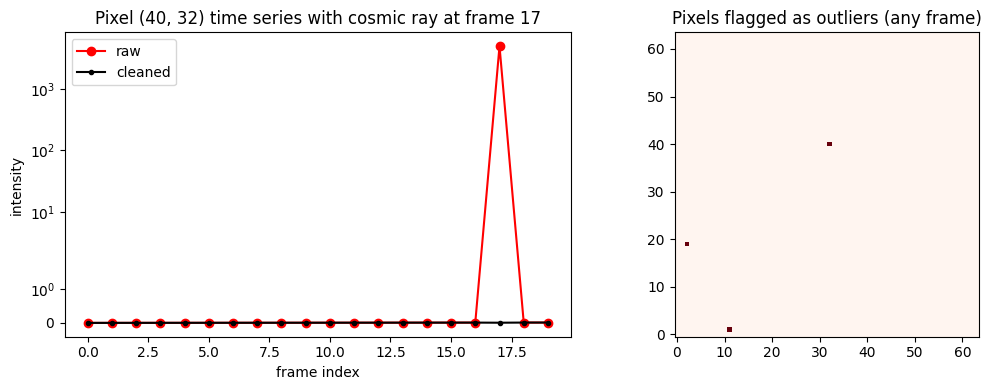

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# Pixel time series at one of the cosmic-ray sites
f, z, y = hits[0]
axes[0].plot(stack[:, z, y], "ro-", label="raw")
axes[0].plot(cleaned[:, z, y], "k.-", label="cleaned")
axes[0].set_xlabel("frame index"); axes[0].set_ylabel("intensity")
axes[0].set_title(f"Pixel ({z}, {y}) time series with cosmic ray at frame {f}")
axes[0].legend(); axes[0].set_yscale("symlog")

# Outlier-mask projection (sum over frames)
axes[1].imshow(outlier_mask.sum(axis=0), cmap="Reds", origin="lower")
axes[1].set_title("Pixels flagged as outliers (any frame)")
plt.tight_layout(); plt.show()


**You should see** the time series spiking at the cosmic-ray frame
(red), with the cleaned line (black) replacing it with the temporal
median.

## Step 3 — Build a frame source from the cleaned stack

For the in-memory case, `NumpyArraySource` wraps the array. In a real
experiment you'd use `HDF5FrameSource` (sweep data is often saved as
HDF5) or `TIFFGlobSource` (one TIFF per frame).


In [5]:
ids = list(monitor_counts.keys())     # 'f000', 'f001', ...
source = NumpyArraySource(cleaned, ids=ids)
print(f"FrameSource: {source.n_frames} frames, {source.frame_shape} pixels")


FrameSource: 20 frames, (64, 64) pixels


## Step 4 — Set up the normaliser

`FrameNormalizer` divides each image by `monitor · exposure_s ·
transmission` (default formula). Pass dicts keyed by frame ID.


In [6]:
normaliser = FrameNormalizer(
    monitor=monitor_counts,
    exposure_s=exposure_s,
)
print("Normalizer ready.")


Normalizer ready.


## Step 5 — Build calibration spec + run the streaming integrate


In [7]:
p = IntegrationParams(
    NrPixelsY=NY, NrPixelsZ=NZ,
    pxY=200.0, pxZ=200.0, Lsd=1_000_000.0,
    BC_y=32.37, BC_z=31.59, RhoD=64.0,
    RMin=1.0, RMax=25.0, RBinSize=0.5,
    EtaMin=-180.0, EtaMax=180.0, EtaBinSize=10.0,
)
spec = spec_from_v1_params(p, requires_grad=False)

result = integrate_stream(
    spec, source,
    mode="polygon",          # exact polygon-area kernel
    normaliser=normaliser,
    progress_every=5,
)
print(f"\nProcessed {result['n_processed']} frames")
print(f"Profile shape per frame: {result['profiles'][0].shape}")


  integrated 5/20 frames
  integrated 10/20 frames
  integrated 15/20 frames
  integrated 20/20 frames

Processed 20 frames
Profile shape per frame: (48,)


**Constant memory** during this loop: only one frame's image lives
in RAM at any moment. The accumulated `profiles` array is small (each
profile is `n_r_bins × float64`, ~400 bytes for our 50-bin demo).


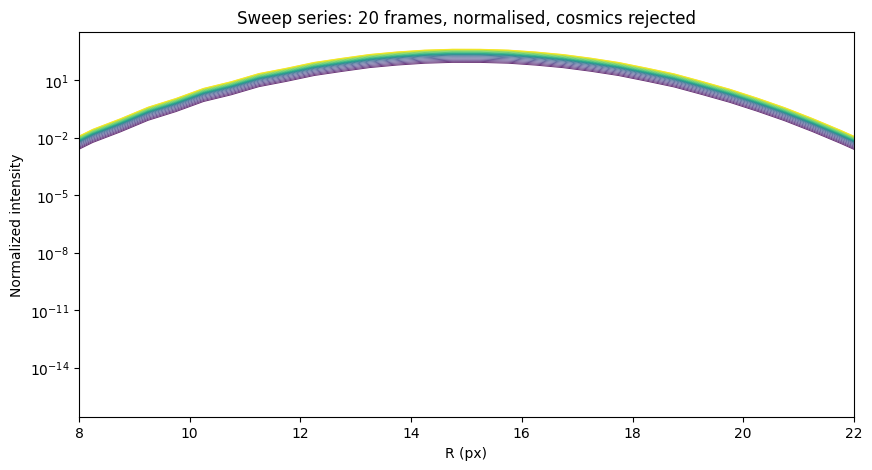

In [8]:
# Plot all 20 profiles to show the time evolution
fig, ax = plt.subplots(figsize=(10, 5))
n_r = spec.n_r_bins
r_axis = spec.RMin + spec.RBinSize * (np.arange(n_r) + 0.5)
cmap = plt.get_cmap("viridis")
for i in range(N_FRAMES):
    ax.plot(r_axis, result["profiles"][i],
            color=cmap(i / (N_FRAMES - 1)),
            lw=0.7, alpha=0.8)
ax.set_xlabel("R (px)"); ax.set_ylabel("Normalized intensity")
ax.set_title(f"Sweep series: {N_FRAMES} frames, normalised, cosmics rejected")
ax.set_yscale("log"); ax.set_xlim(8, 22)
plt.show()


**You should see** the integrated peak grow over the 20 frames (since
we synthesised increasing intensity). The cosmic-ray-affected frames
should NOT show spurious spikes — that's the rejection working.

## Step 6 — Write a single HDF5 with all profiles + metadata

`write_h5` stacks them into one file with embedded provenance. Easy
to load months later for re-analysis.


In [9]:
out_dir = Path.cwd() / "v08_sweep_outputs"
out_dir.mkdir(exist_ok=True, parents=True)

md = build_provenance(
    spec, integrate_mode="polygon",
    extra={
        "n_frames":      N_FRAMES,
        "cosmic_n_caught": int(outlier_mask.sum()),
        "cosmic_n_sigma":  5.0,
    },
)

out = out_dir / "sweep.h5"
write_h5(
    out,
    profiles=result["profiles"],
    r_axis=result["r_axis_px"],
    frame_ids=result["frame_ids"],
    metadata=md,
    extra_datasets={
        "monitor_counts": np.array([monitor_counts[fid] for fid in ids]),
        "exposure_s":     np.array([exposure_s[fid] for fid in ids]),
    },
)
print(f"wrote {out}, {out.stat().st_size / 1e3:.1f} KB")


wrote /Users/hsharma/opt/MIDAS/packages/midas_integrate_v2/notebooks/v08_sweep_outputs/sweep.h5, 24.3 KB


In [10]:
# Verify the HDF5 file's structure
import h5py
with h5py.File(out, "r") as f:
    print(f"datasets: {list(f.keys())}")
    print(f"profiles shape: {f['profiles'].shape}")
    print(f"frame_ids[0..2]: {[s.decode() for s in f['frame_ids'][:3]]}")
    print(f"monitor_counts[0..2]: {f['monitor_counts'][:3]}")
    if 'metadata_json' in f.attrs:
        import json
        meta = json.loads(f.attrs['metadata_json'])
        print(f"metadata package: {meta['package']}")
        print(f"metadata extra: {meta.get('extra', {})}")


datasets: ['exposure_s', 'frame_ids', 'monitor_counts', 'profiles', 'r_axis_px']
profiles shape: (20, 48)
frame_ids[0..2]: ['f000', 'f001', 'f002']
monitor_counts[0..2]: [1.         1.03271947 1.06183698]
metadata package: midas_integrate_v2
metadata extra: {'n_frames': 20, 'cosmic_n_caught': 3, 'cosmic_n_sigma': 5.0}


## Step 7 — Use the CLI for production runs

The CLI wraps the above into one command:

```bash
midas-integrate-v2-batch paramstest.txt \
    --hdf5 sweep_input.h5 \
    --mode polygon \
    --reject-outliers-sigma 5.0 \
    --out-dir out/ \
    --out-format h5
```

For a TIFF directory:

```bash
midas-integrate-v2-batch paramstest.txt \
    --image-glob 'frames/*.tif' \
    --mode subpixel -K 4 \
    --mask bad_pixels.tif \
    --out-dir profiles/ \
    --out-format xye
```

Each frame writes one XYE for direct use with Rietveld tools.


## Common pitfalls

1. **Memory blow-up from outlier rejection on TIFF glob**: outlier
   rejection needs the whole stack to compute per-pixel statistics
   across frames. For 1000+ Pilatus frames that's 30+ GB. Use HDF5
   input (`--hdf5`) so the rejection can stream.
2. **Wrong normalisation formula**: some beamlines monitor as a *rate*
   (counts per second), not absolute counts. Then you should divide
   by `monitor` (not `monitor · exposure_s`). Use `FrameNormalizer`'s
   `formula=...` argument to override.
3. **Missing frame IDs in `monitor` dict**: a frame ID that's not in
   the dict gets a default factor of 1.0 (no normalisation). Confirm
   your IDs match (typo in keys is a common bug).
4. **Cosmic-ray rejection on non-uniform stacks**: if your sample
   really IS changing fast (one frame is super bright, the next is
   normal), the bright frame might get classified as an outlier.
   Lower `n_sigma` or skip cosmic-ray rejection for time-resolved
   experiments where each frame is unique.

## Try it yourself

1. **Run on a Pilatus sweep**: replace the synthetic stack with a real
   Pilatus HDF5 and a paramstest from notebook 09.
2. **Vary `n_sigma`**: try 3.0 vs 7.0 vs 10.0. How many false
   positives at each? (For Gaussian noise: 5σ is ~2 ppm chance per
   pixel; with 16M pixels you expect ~30 false positives.)
3. **Compare integration modes**: run the same sweep through
   `mode='hard'` vs `'subpixel'` (K=4) vs `'polygon'`. How much faster
   is hard? How much sharper are the peaks in polygon?
4. **Add a CLI workflow**: write a shell script that calls
   `midas-integrate-v2-batch` on a directory of sweeps, produces a
   timestamped output directory per sweep, and copies them to
   archival storage.

## You're (truly) done

Eleven notebooks, 174+ tests, end-to-end coverage from "what's a
detector" to "deploy a sweep-mode pipeline". `midas-integrate-v2` is
production-complete.
